In [1]:
import pandas as pd
import cygno as cygno
import glob
import uproot 
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import awkward as ak
from tqdm.notebook import tqdm
import os
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

In [6]:
!git --version
!git config --global user.name "Fernando"
!git config --global user.email "famaro@gian.fis.uc.pt"
!git init
!git add .
!git commit -m "Initial commit"
!git rm -r --cached 001_environmental_paramters_SAVE_DATA
!git commit -m "removed output folder"
!git branch -M main


git version 2.29.2


In [18]:
!git remote set-url origin https://github.com/CYGNO-Analysis/Run4_lowgain.git
!git push -u origin main

Username for 'https://github.com': ^C


In [23]:
!ssh-keygen -t ed25519 -f ~/.ssh/id_ed25519 -N "" -C "famaro@gian.fis.uc.pt"

Generating public/private ed25519 key pair.
Created directory '/home/root/.ssh'.
Your identification has been saved in /home/root/.ssh/id_ed25519
Your public key has been saved in /home/root/.ssh/id_ed25519.pub
The key fingerprint is:
SHA256:CDLw9sbmOHb2XYWWHRbPZnT3kW46WEc1rx3jtDSWu74 famaro@gian.fis.uc.pt
The key's randomart image is:
+--[ED25519 256]--+
|.           . .o*|
| o           = +B|
|  = .       o BOo|
| . = . .   = ==**|
|    = . S + = =+.|
|   =     . o o  .|
|  + +     .   .. |
| . + . . .    .  |
|      . .      E.|
+----[SHA256]-----+


In [24]:
!cat ~/.ssh/id_ed25519.pub 

ssh-ed25519 AAAAC3NzaC1lZDI1NTE5AAAAICn11TkydaMI1ueSdIqgagxAlX+eIyVFCPpTYfE3fmME famaro@gian.fis.uc.pt


In [26]:
!git clone git@github.com:CYGNO-Analysis/Run4_lowgain

Cloning into 'Run4_lowgain'...
The authenticity of host 'github.com (140.82.121.4)' can't be established.
ED25519 key fingerprint is SHA256:+DiY3wvvV6TuJJhbpZisF/zLDA0zPMSvHdkr4UvCOqU.
This key is not known by any other names
Are you sure you want to continue connecting (yes/no/[fingerprint])? ^C


In [27]:
!ssh-keyscan github.com >> ~/.ssh/known_hosts

# github.com:22 SSH-2.0-fa646f3
# github.com:22 SSH-2.0-fa646f3
# github.com:22 SSH-2.0-fa646f3
# github.com:22 SSH-2.0-fa646f3
# github.com:22 SSH-2.0-fa646f3


In [28]:
!ssh -o BatchMode=yes -T git@github.com

Hi famaro77! You've successfully authenticated, but GitHub does not provide shell access.


In [29]:
!git clone git@github.com:CYGNO-Analysis/Run4_lowgain.git

Cloning into 'Run4_lowgain'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 15 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 4.66 KiB | 4.66 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [50]:
!cd Run4_lowgain

In [52]:
!git commit -m "initial commit"

[main fb46284] initial commit
 3720 files changed, 124 deletions(-)
 delete mode 100644 001_environmental_paramters_SAVE_DATA/.ipynb_checkpoints/histo_sc_integral_42856_step5-checkpoint.png
 delete mode 100644 001_environmental_paramters_SAVE_DATA/.ipynb_checkpoints/histo_sc_integral_42857_step4-checkpoint.png
 delete mode 100644 001_environmental_paramters_SAVE_DATA/.ipynb_checkpoints/predictors_heatmap-checkpoint.png
 delete mode 100644 001_environmental_paramters_SAVE_DATA/.ipynb_checkpoints/sc_integral_mean_values_15.0-checkpoint.png
 delete mode 100644 001_environmental_paramters_SAVE_DATA/R_values_.png
 delete mode 100644 001_environmental_paramters_SAVE_DATA/R_values_['Atm_pressure'].png
 delete mode 100644 001_environmental_paramters_SAVE_DATA/R_values_['Atm_temperature'].png
 delete mode 100644 001_environmental_paramters_SAVE_DATA/R_values_['Humidity'].png
 delete mode 100644 001_environmental_paramters_SAVE_DATA/R_values_['Lime_pressure', 'Atm_pressure', 'Lime_temperature', 

In [54]:
!git push --set-upstream origin main


Username for 'https://github.com': ^C


In [2]:
from configs import *
from functions import *

In [3]:
f"setting the folder to save the outputs"
main_folder_to_save = '001_environmental_paramters_SAVE_DATA'
if not os.path.exists(main_folder_to_save):
    os.makedirs(main_folder_to_save)

In [4]:
f"reading logbook"
logbook_df = cygno.read_cygno_logbook()
logbook_df = logbook_df.rename(columns={'run_number' : 'run'})

In [5]:
logbook_df.columns

Index(['run', 'run_description', 'start_time', 'exposure_sec', 'GEM3_V',
       'GEM2_V', 'GEM1_V', 'T2_V', 'T1_V', 'DRIFT_V', 'OFFSET_V', 'PMT1_V',
       'PMT2_V', 'PMT3_V', 'PMT4_V', 'HV_STATE', 'total_gas_flow',
       'sequencer_running', 'sequence_filename', 'pmt_acquisition',
       'pedestal_run', 'source_type', 'source_position',
       'discrimination_threshold', 'trigger_veto_time', 'trigger_logic',
       'run_type', 'drs4_correction_active', 'shielding_configuration',
       'stop_time', 'number_of_events', 'storage_local_status',
       'storage_cloud_status', 'storage_tape_status', 'file_size',
       'file_checksum', 'file_s3_tag', 'online_reco_status', 'run_quality'],
      dtype='object')

In [6]:
for source in logbook_df.source_type.unique():
    print(source)
    if source == 1.0: continue
    print(f"{logbook_df[logbook_df.source_type == source].run_description.unique()}")
    

nan
[]
1.0
0.0
['test DAQ' 'Standard' 'Daily Calibration, parking' 'test'
 'Garbage (cathode was Off)' 'Garbage'
 'Daily Calibration - LOW Gain, parking' 'Standard - LOW Gain'
 'VGEM1 scan, parking position' 'Stability - LOW Gas Flow : 2 l/h'
 'Daily Calibration, parking, Low Gain' 'Standard, Low Gain'
 'Saturation Scouting, Pedestal'
 'Low Drift Field Calibration, parking, Low Gain'
 'Standard, Low Gain, Low Drift Field' 'garbage' ' garbage'
 'Camera and PMT pedestals' 'Quest - LED' 'Quest - 55Fe Step 3'
 'QUEST Daily Calibration, parking' 'QUEST Camera and PMT pedestals'
 'FUSION Daily Calibration, parking' 'Pedestal for NID'
 'NID operation - 570 V' 'Pedestal' 'NID operation - 560 V'
 'NID operation - 540 V' 'NID operation - 530 V - 1.2% SF6'
 'NID operation - 550 V - 1.2% SF6' 'NID operation - 555 V - 1.2% SF6'
 'NID operation - 560 V - 1.2% SF6' 'NID operation - 565 V - 1.2% SF6'
 'NID operation - 570 V - 1.2% SF6' 'NID operation - 575 V - 1.2% SF6'
 'NID operation - 580 V - 1.2% 

In [7]:
f"setting the mask for run selection"
selected_gem_voltage = 400

mask = (  (logbook_df['source_type'] == 1)
       & (logbook_df.run >= lime_underground_run_numbers_dict['Run 4'][0])
       & (logbook_df.run <= lime_underground_run_numbers_dict['Run 4'][1]) 
       & (logbook_df.run_description.isin(steps_of_interest) ) 
       & (logbook_df.GEM1_V == selected_gem_voltage)     
       )

In [8]:
f"doing the selection"
selected_runs_df = (logbook_df[mask].copy())
begining = selected_runs_df.iloc[0]['start_time']
ending = selected_runs_df.iloc[-1]['start_time']
print(f"found {len(selected_runs_df)} runs between {begining} and {ending}")

found 51 runs between 2023-12-14 17:36:39 and 2024-03-12 08:54:57


In [9]:
all_run_numbers_list = selected_runs_df.run.unique()
print(len(all_run_numbers_list))

51


In [10]:
low_gain_run_list = selected_runs_df.run.values
low_gain_run_list

array([42856, 42857, 42858, 42859, 42860, 43067, 43068, 43069, 43070,
       43071, 50901, 50902, 50903, 50904, 50905, 50952, 50953, 50954,
       50955, 50956, 50957, 51029, 51030, 51031, 51032, 51033, 51103,
       51104, 51105, 51106, 51107, 51179, 51180, 51181, 51182, 51183,
       51314, 51315, 51316, 51317, 51318, 51400, 51401, 51402, 51403,
       51404, 51886, 51887, 51888, 51889, 51890])

In [11]:
low_gain_start_times = selected_runs_df.start_time.values
low_gain_start_times

array(['2023-12-14T17:36:39.000000000', '2023-12-14T17:44:21.000000000',
       '2023-12-14T17:49:01.000000000', '2023-12-14T17:53:20.000000000',
       '2023-12-14T17:57:18.000000000', '2023-12-15T17:31:28.000000000',
       '2023-12-15T17:33:51.000000000', '2023-12-15T17:36:31.000000000',
       '2023-12-15T17:39:27.000000000', '2023-12-15T17:42:06.000000000',
       '2024-03-05T10:19:21.000000000', '2024-03-05T10:21:19.000000000',
       '2024-03-05T10:26:25.000000000', '2024-03-05T10:29:49.000000000',
       '2024-03-05T10:34:19.000000000', '2024-03-05T18:38:12.000000000',
       '2024-03-05T18:40:16.000000000', '2024-03-05T18:42:24.000000000',
       '2024-03-05T18:44:41.000000000', '2024-03-05T18:46:53.000000000',
       '2024-03-05T18:48:36.000000000', '2024-03-06T07:24:48.000000000',
       '2024-03-06T07:28:10.000000000', '2024-03-06T07:31:38.000000000',
       '2024-03-06T07:44:06.000000000', '2024-03-06T07:46:19.000000000',
       '2024-03-06T20:04:41.000000000', '2024-03-06

In [12]:
f"removing runs within an interval n hours after the flow was not 5"
hours_before_normal_flow = '72H'
selected_runs_df['flow_prev'] = selected_runs_df['total_gas_flow'].shift()
transition_times = selected_runs_df.loc[(selected_runs_df['total_gas_flow'] == 5) &
                          (selected_runs_df['flow_prev'] != 5), 'start_time']

mask_remove = pd.Series(False, index=selected_runs_df.index)
for t in transition_times:
    window_end = t + pd.Timedelta(hours=2)
    mask_remove |= (selected_runs_df['start_time'] >= t) & (selected_runs_df['start_time'] <= window_end)

#selected_runs_df = selected_runs_df.loc[~mask_remove].drop(columns=['flow_prev'])
print(f"found {len(selected_runs_df)} runs between {begining} and {ending}")

found 51 runs between 2023-12-14 17:36:39 and 2024-03-12 08:54:57


In [13]:
runs_after_normal_flow_set = selected_runs_df.loc[mask_remove].run.values

In [14]:
f"removing low flow runs"
if selected_gem_voltage == 440: 
    mask_flow = ((logbook_df.total_gas_flow == 5))
    #selected_runs_df = (selected_runs_df[mask_flow])
print(f"found {len(selected_runs_df)} runs between {begining} and {ending}")

found 51 runs between 2023-12-14 17:36:39 and 2024-03-12 08:54:57


In [16]:
selected_gem_voltage

400

In [15]:
runs_at_normal_flow_set = selected_runs_df[mask_flow].run.values

NameError: name 'mask_flow' is not defined

In [17]:
for col in selected_runs_df[['GEM3_V',
       'GEM2_V', 'GEM1_V', 'T2_V', 'T1_V', 'DRIFT_V', 'OFFSET_V', 'PMT1_V',
       'PMT2_V', 'PMT3_V', 'PMT4_V', 'HV_STATE', 'total_gas_flow','run_quality']].columns:
    print(f"{col}-{selected_runs_df[col].unique()}")

GEM3_V-[400]
GEM2_V-[400]
GEM1_V-[400]
T2_V-[500]
T1_V-[500]
DRIFT_V-[960]
OFFSET_V-[10]
PMT1_V-[772]
PMT2_V-[772]
PMT3_V-[800]
PMT4_V-[770 772]
HV_STATE-[1]
total_gas_flow-[5.]
run_quality-[-1]


In [18]:
for gas_flow in selected_runs_df['total_gas_flow'].unique():
    size = len(selected_runs_df[selected_runs_df['total_gas_flow'] ==gas_flow])
    print(f"{gas_flow}: {size} ")

5.0: 51 


In [19]:
f"adding the calibration number to the selected runs"
selected_runs_df['calibration_number'] = (selected_runs_df['start_time'].diff() > pd.Timedelta('120min')).cumsum()
print(f"found {selected_runs_df['calibration_number'].max()} calibration sets")

found 9 calibration sets


In [20]:
f"correcting positions"
selected_runs_df['corrected_source_position'] = (selected_runs_df['source_position']).map(wrong_to_wright_position_dict)

In [21]:
f"adding step information"
selected_runs_df['step'] = (selected_runs_df['corrected_source_position']).map(correct_position_to_step_dict)

In [22]:
f"creating the list of runs"
run_list_to_load = all_run_numbers_list#selected_runs_df['run']#[0:2]

In [23]:
f"setting the path to the cloud folder with the data"
run_to_analyse = f"Run4"
data_directory = f"/jupyter-workspace/cnaf-storage/cygno-analysis/RECO/{run_to_analyse}"

In [24]:
f"loading the rectangular data"
rectangular_data_df = load_rectangular_data(run_list_to_load, data_directory)

loading from /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run42856_3D.root
loading from /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run42857_3D.root
loading from /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run42858_3D.root
loading from /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run42859_3D.root
loading from /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run42860_3D.root
loading from /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run43067_3D.root
loading from /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run43068_3D.root
loading from /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run43069_3D.root
loading from /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run43070_3D.root
loading from /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run43071_3D.root
loading from /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run50

In [25]:
f"selecting environmental data for each run, by averaging the values on rectangular data for the events"
environmental_df = rectangular_data_df.groupby("run")[['Lime_pressure', 'Atm_pressure',
       'Lime_temperature', 'Atm_temperature', 'Humidity', 'Mixture_Density']].mean().reset_index()

In [26]:
rectangular_data_df.columns

Index(['run', 'event', 'pedestal_run', 'cmos_integral', 'cmos_mean',
       'cmos_rms', 't_DBSCAN', 't_variables', 'lp_len', 't_pedsub',
       't_saturation', 't_zerosup', 't_xycut', 't_rebin', 't_medianfilter',
       't_noisered', 'nSc', 'nRedpix', 'Lime_pressure', 'Atm_pressure',
       'Lime_temperature', 'Atm_temperature', 'Humidity', 'Mixture_Density'],
      dtype='object')

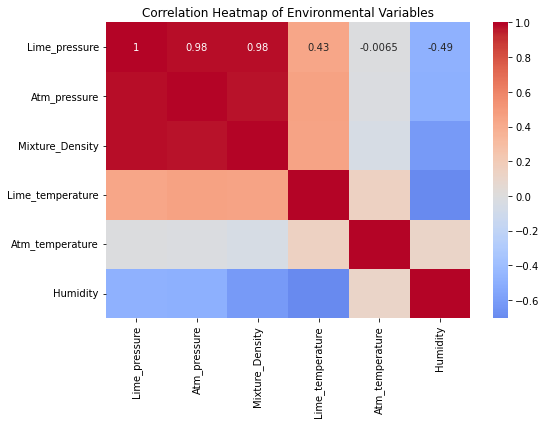

In [27]:
f"checking correlations between environmental variables"
predictors = ['Lime_pressure', 'Atm_pressure', 'Mixture_Density', 'Lime_temperature', 
              'Atm_temperature', 'Humidity', ]

corr_matrix = environmental_df[predictors].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Environmental Variables")
plt.tight_layout()

plt.savefig(os.path.join(main_folder_to_save, 'predictors_heatmap.png'))
plt.show()

In [28]:
f"Lime_pressure, Atm_pressure and Mixture_Density are highly correlated, so we drop the two later"
predictors = [x for x in predictors if x not in ['Mixture_Density', 'Atm_pressure']]

In [29]:
f"loading jagged data"
jagged_data_df = load_jagged_data(run_list_to_load, data_directory)

In [30]:
f"renaming run column for consistency with other data sources"
jagged_data_df = jagged_data_df.rename(columns = {'Run':'run'})

In [31]:
jagged_data_df.columns

Index(['sc_size', 'sc_nhits', 'sc_integral', 'sc_corrintegral', 'sc_rms',
       'sc_energy', 'sc_pathlength', 'sc_theta', 'sc_length', 'sc_width',
       'sc_longrms', 'sc_latrms', 'sc_lfullrms', 'sc_tfullrms',
       'sc_lp0amplitude', 'sc_lp0prominence', 'sc_lp0fwhm', 'sc_lp0mean',
       'sc_tp0fwhm', 'sc_xmean', 'sc_ymean', 'sc_xmax', 'sc_xmin', 'sc_ymax',
       'sc_ymin', 'sc_pearson', 'sc_tgaussamp', 'sc_tgaussmean',
       'sc_tgausssigma', 'sc_tchi2', 'sc_tstatus', 'sc_lgaussamp',
       'sc_lgaussmean', 'sc_lgausssigma', 'sc_lchi2', 'sc_lstatus', 'run'],
      dtype='object')

In [32]:
f"setting a dict with the limits for ploting each sc_variable"
# {'sc_variable':[x_min, x_limit, y_min, y_limit]}
limits_for_sc_variable_dict = {'sc_integral'   :[600,25000,0,220],
                               'sc_tgausssigma':[0,20,0,350],
                               'sc_tfullrms'   :[0,20,0,450],
                               'sc_nhits'      :[220,2500,0,600],
                              # 'sc_size '      :[500,4500,0,600],
                               'sc_rms'        :[0,20,0,700],
                               #'sc_pathlength' :[-.1,-.91,0,1200],
                               'sc_theta'    : [-360,360, 0, 600]
                              }

In [33]:
runs_to_analyse = run_list_to_load#selected_runs_df.run.unique()
print(f" loading {len(runs_to_analyse)} runs")

 loading 51 runs


In [34]:
#f"removing problematic runs"
problematic_runs = [[52659, 53002]] 

runs_to_analyse = [run for run in runs_to_analyse 
    if not any(min_val <= run <= max_val for min_val, max_val in problematic_runs)]
print(f" loading {len(runs_to_analyse)} runs")

 loading 51 runs


In [35]:
#f"selecting runs at normal flow"
runs_at_normal_flow_set # select these runs
runs_to_analyse = [run for run in runs_to_analyse if run in runs_at_normal_flow_set]
print(f" loading {len(runs_to_analyse)} runs")

NameError: name 'runs_at_normal_flow_set' is not defined

In [36]:
#f"removing runs shortly after normal flow"
runs_after_normal_flow_set # remove these ones
runs_to_analyse = [run for run in runs_to_analyse if run not in runs_after_normal_flow_set]
print(f" loading {len(runs_to_analyse)} runs")

 loading 46 runs


In [37]:
print(f" loading {len(runs_to_analyse)} runs")


 loading 46 runs


In [38]:
runs_to_analyse = [run for run in runs_at_normal_flow_set if run < 52000]

NameError: name 'runs_at_normal_flow_set' is not defined

In [39]:
runs_to_analyse = [run for run in runs_to_analyse if any(abs(run-rb)<=20 for rb in low_gain_run_list)]

In [40]:
#f"initialzie resutl df"
result_df = selected_runs_df.loc[selected_runs_df['run'].isin(runs_to_analyse)]

In [41]:
sc_variable = 'sc_integral'
#sc_variable = 'sc_tgausssigma'
#sc_variable = 'sc_tfullrms'
sc_variable = 'sc_nhits'
sc_variable = 'sc_size'
#sc_variable = 'sc_rms'
#sc_variable = 'sc_pathlength'
#sc_variable = 'sc_energy'
#sc_variable = 'sc_theta'

#[' 'sc_corrintegral', '',
#    'sc_theta', 'sc_length', 'sc_width',
#   #'sc_longrms', 'sc_latrms', 
#          'sc_lfullrms', 'sc_tfullrms',
#   'sc_lp0amplitude', 'sc_lp0prominence', 'sc_lp0fwhm', 'sc_lp0mean',
#   'sc_tp0fwhm', 'sc_xmean', 'sc_ymean', 'sc_xmax', 'sc_xmin', 'sc_ymax',
#   'sc_ymin', 'sc_pearson', 'sc_tgaussamp', 'sc_tgaussmean',
   #
#          'sc_tchi2', 'sc_tstatus', 'sc_lgaussamp',
#   'sc_lgaussmean', 'sc_lgausssigma', 'sc_lchi2', 'sc_lstatus'
#         ]


In [42]:
f"making fits and extracting parameters from jagged data"

fit_parameters_list = []
fit_errors_list = []
run_number_list = []
for run_number in runs_to_analyse:#selected_runs_df.run.unique():# jagged_data_df.run.unique():

    
    bins = 60
    if sc_variable in limits_for_sc_variable_dict.keys():
        x_min   = limits_for_sc_variable_dict[sc_variable][0]
        x_limit = limits_for_sc_variable_dict[sc_variable][1]
        y_min   = limits_for_sc_variable_dict[sc_variable][2]
        y_limit = limits_for_sc_variable_dict[sc_variable][3]
    
        
    if (sc_variable == 'sc_nhits' and run_number >=43067 and run_number <=43071) : x_min   = 0
    if (sc_variable == 'sc_size'  and run_number >=52659 and run_number <=53002) : x_min   = 500
    label = ""
    title = ""
    
    fit_params = np.nan
    fit_errors = np.nan
    loaded_data = pd.DataFrame()
    loaded_data_bol = False
    step   = selected_runs_df[selected_runs_df.run == run_number].step.values[0]
    gem3_V = selected_runs_df[selected_runs_df.run == run_number].GEM3_V.values[0]
    #if gem3_V == 400: x_limit = 4000
    print("\t")
    print(f"-> loading events for {run_number} which corresponds to {step}")
   
    loaded_data = jagged_data_df[jagged_data_df.run == run_number]
    loaded_data = loaded_data[(loaded_data[sc_variable] > x_min) & (loaded_data[sc_variable] < x_limit)]
    title = f"{run_number} / {step} / GEM3 : {gem3_V} V"
   
    array_for_fit = loaded_data[sc_variable]
    path_to_save_figure = os.path.join(main_folder_to_save, f'histo_{sc_variable}_{run_number}_{step}_{gem3_V}.png')
    try:
        fit_params, fit_errors = fit_gaussian_to_histogram_absolute(array_for_fit, bins, x_limit, y_limit, label, title, sc_variable,path_to_save_figure)
    except Exception as e:
        print(f"An error occurred: {e}")
        fit_params = np.nan
        fit_errors = np.nan
    fit_parameters_list.append(fit_params)
    fit_errors_list.append(fit_errors)
    run_number_list.append(run_number)
    

	
-> loading events for 43067 which corresponds to step1


NameError: name 'x_min' is not defined

In [441]:
fit_parameters_list

[array([198.86657601, 385.16619731, 101.9958983 ]),
 array([290.88057306, 387.26138991,  95.71029996]),
 array([308.86939167, 370.516207  ,  85.56659932]),
 array([357.32438293, 342.76489302,  76.16327529]),
 array([322.85115781, 292.72263235,  81.79672843]),
 array([587.70067121, 203.44961269,  45.04410758]),
 array([657.90713089, 230.04585132,  45.46250585]),
 array([624.96829604, 242.55044373,  49.01274935]),
 array([512.37665087, 239.10997564,  54.76347664]),
 array([330.03933046, 234.99941682,  57.85672965]),
 array([260.73733418, 305.83952796,  97.72130948]),
 array([304.71442578, 363.38214798,  87.70462858]),
 array([302.12922271, 395.78825634,  88.10903699]),
 array([255.77636102, 415.49706945,  92.95921295]),
 array([185.88003995, 419.90534449, 110.45753382]),
 array([299.58524867, 308.64545443,  85.3814333 ]),
 array([314.11117794, 356.53419542,  82.01732539]),
 array([304.9138669 , 388.73618763,  80.52713718]),
 array([262.04807442, 401.58571779,  95.95383379]),
 array([203.

In [442]:
f"scaling down the select runs information"
selected_runs_df = selected_runs_df[['run', 'run_description', 'start_time', 'exposure_sec', 'GEM3_V',
       'GEM2_V', 'GEM1_V', 'T2_V', 'T1_V', 'DRIFT_V', 'OFFSET_V', 'PMT1_V',
       'PMT2_V', 'PMT3_V', 'PMT4_V', 'HV_STATE', 'total_gas_flow',
       'calibration_number', 'corrected_source_position', 'step']]

In [443]:
logbook_df.columns

Index(['run', 'run_description', 'start_time', 'exposure_sec', 'GEM3_V',
       'GEM2_V', 'GEM1_V', 'T2_V', 'T1_V', 'DRIFT_V', 'OFFSET_V', 'PMT1_V',
       'PMT2_V', 'PMT3_V', 'PMT4_V', 'HV_STATE', 'total_gas_flow',
       'sequencer_running', 'sequence_filename', 'pmt_acquisition',
       'pedestal_run', 'source_type', 'source_position',
       'discrimination_threshold', 'trigger_veto_time', 'trigger_logic',
       'run_type', 'drs4_correction_active', 'shielding_configuration',
       'stop_time', 'number_of_events', 'storage_local_status',
       'storage_cloud_status', 'storage_tape_status', 'file_size',
       'file_checksum', 'file_s3_tag', 'online_reco_status', 'run_quality'],
      dtype='object')

In [444]:
f"adding the fit amplitue, mean and sigma to the selected runs information"
result_df[f'fit_{sc_variable}_ampl']  = [x[0] for x in fit_parameters_list]
result_df[f'fit_{sc_variable}_mean']  = [x[1] for x in fit_parameters_list]
result_df[f'fit_{sc_variable}_sigma'] = [x[2] for x in fit_parameters_list]

In [445]:
f"merging the environmental information to the selected runs information"
result_df = result_df.merge(
    environmental_df[['run', 'Lime_pressure', 'Atm_pressure', 
                      'Lime_temperature', 'Atm_temperature', 
                      'Humidity', 'Mixture_Density']],
    on='run',
    how='left'
)

In [401]:
result_df = result_df.rename(columns = {'Lime_temperature_x': 'Lime_temperature',
                                        'Lime_pressure_x':'Lime_pressure',
                                        'Atm_pressure_x':'Atm_pressure',
                                        'Atm_temperature_x':'Atm_temperature',
                                        'Humidity_x':'Humidity',
                                        'Mixture_Density_x':'Mixture_Density'})

In [446]:
result_df['P/T'] = result_df['Lime_pressure']/result_df['Lime_temperature']

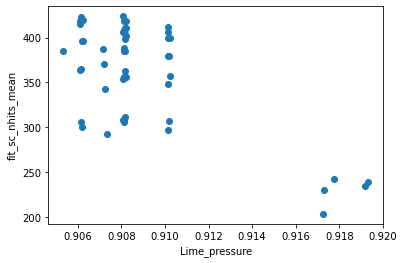

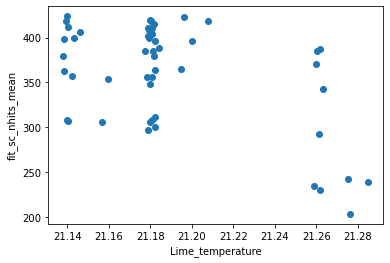

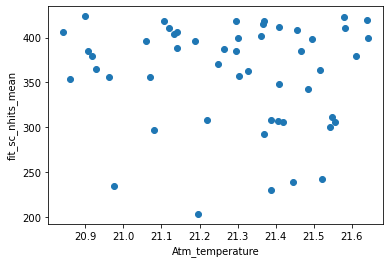

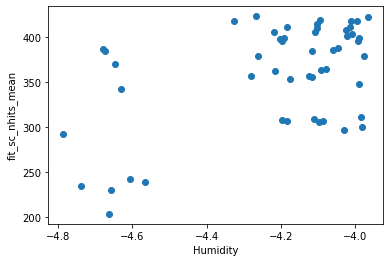

In [447]:
f"ploting environmental variables vs sc_variable"
for predictor in predictors:
    plt.scatter( result_df[predictor], result_df[f"fit_{sc_variable}_mean"])
    plt.xlabel(f"{predictor}")
    plt.ylabel(f"fit_{sc_variable}_mean")
    plt.savefig(os.path.join(main_folder_to_save, f'{sc_variable}_vs_{predictor}_{gem3_V}.png'))
    plt.show()

In [448]:
metrics_by_model = {}

y = 2.068e+04 + -1.009e+04*Lime_pressure + -518.8*Lime_temperature + 29.27*Humidity


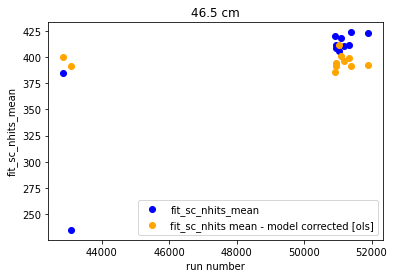

y = 1.738e+04 + -1.074e+04*Lime_pressure + -339*Lime_temperature + 11.16*Humidity


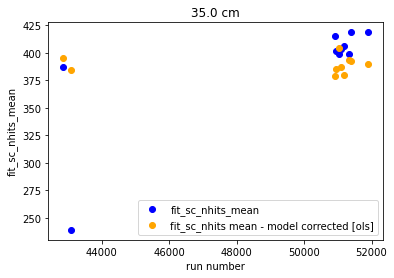

y = 1.695e+04 + -1.04e+04*Lime_pressure + -333.5*Lime_temperature + 13.91*Humidity


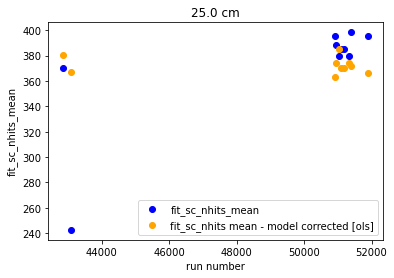

y = 1.625e+04 + -9619*Lime_pressure + -337.4*Lime_temperature + 2.47*Humidity


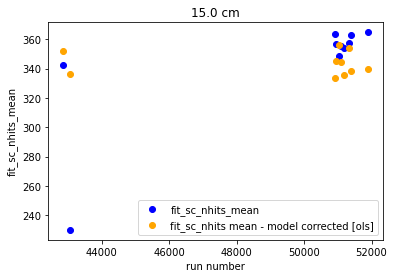

y = 1.35e+04 + -6912*Lime_pressure + -328.1*Lime_temperature + -6.978*Humidity


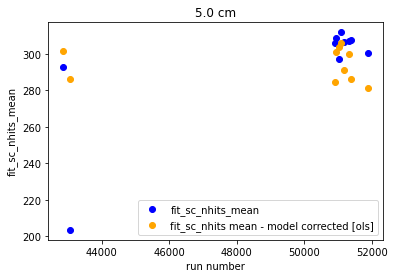

In [452]:
import random

pos_to_scale_dict = {5.0 :[4800, 8000],
                     15.0:[6000,10500],
                     25.0:[6500,12400],
                     35.0:[6500,13500],
                     46.5:[5900,14000]}

# Applying Linear Regression models for each position (target = sc_integral, predictors = environmental variables)
p_values_by_position_dict = {}
R_values_by_position_dict = {}
corrected_means_dict = {}
run_numbers_dict = {}

metrics_by_position = {}
params_dict = {}

# Selecting model to use
model_selected = 'ols'
#model_selected = 'xgb_reg'
#model_selected = 'log_transform'
predictors_shuffle = False  # for sanity checks

for position in result_df.corrected_source_position.unique():
    
    # Select data for this position
    df_to_plot = result_df[result_df.corrected_source_position == position].copy()
    
    # Plot raw (non-corrected)
    plt.scatter(df_to_plot.run, df_to_plot[f'fit_{sc_variable}_mean'], marker='o',
                color='blue', label=f'fit_{sc_variable}_mean')
    plt.title(f"{position} cm")
    plt.xlabel('run number')
    plt.ylabel(f'fit_{sc_variable}_mean')
    #plt.ylim(pos_to_scale_dict[position][0],pos_to_scale_dict[position][1])
    #plt.ylim(5000, 14000)
    #plt.ylim(3.5,6.5)
    #plt.ylim(400,920)
    plt.legend()
    plt.savefig(os.path.join(main_folder_to_save,
                             f'{sc_variable}_mean_values_{position}_{gem3_V}.png'))
    
    # Select predictors
    predictors = [
        'Lime_pressure', 'Atm_pressure',
        'Lime_temperature', 
        'Humidity', 'Mixture_Density'
    ]
    
    # Remove some predictors
    predictors = [x for x in predictors if x not in [
        'Atm_pressure', 'Mixture_Density', 'Atm_temperature'
    ]]
    
    # X matrix
    X = df_to_plot[predictors]

    # Shuffle predictors if requested
    if predictors_shuffle:
        print("Shuffling predictors")
        X = pd.DataFrame(
            np.random.randn(len(df_to_plot), len(predictors)),
            columns=predictors,
            index=df_to_plot.index
        )
    
    # Target
    y = df_to_plot[f'fit_{sc_variable}_mean']

    # -------------------------------
    # OLS or log-transform OLS
    # -------------------------------
    if model_selected in ['ols', 'log_transform']:

        use_log = (model_selected == 'log_transform')
        
        if use_log:
            y_safe = y.clip(lower=1e-9)
            y_model = np.log(y_safe)
        else:
            y_model = y
        
        X_const = sm.add_constant(X)
        model = sm.OLS(y_model, X_const)
        results = model.fit()

        #f"printing the formula"
        params = results.params
        formula = "y = "
        formula += " + ".join(
            [f"{params[i]:.4g}*{i}" if i != "const" else f"{params[i]:.4g}"
             for i in params.index]
        )
        params_dict[position]= params
        print(formula)

        R_values_by_position_dict[position] = results.rsquared
        p_values_by_position_dict[position] = results.pvalues

        if use_log:
            fitted_log = results.fittedvalues
            value_corrected = np.exp(fitted_log)
        else:
            value_corrected = results.resid + y.mean()

        corrected_means_dict[position] = value_corrected
    
    # -------------------------------
    # XGBoost model
    # -------------------------------
    elif model_selected == 'xgb_reg':
        import xgboost as xgb
        from sklearn.model_selection import KFold
        
        model = xgb.XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            min_child_weight=3,
            gamma=0.0,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.5,
            reg_lambda=1.0,
            objective="reg:squarederror",
            tree_method="hist",
            n_jobs=-1,
            random_state=42,
            verbosity=1
        )

        kf = KFold(n_splits=5, shuffle=True, random_state=0)
        y_cv_pred = np.zeros(len(X))

        for train_idx, val_idx in kf.split(X):
            model.fit(X.iloc[train_idx], y.iloc[train_idx])
            y_cv_pred[val_idx] = model.predict(X.iloc[val_idx])

        value_corrected = y - y_cv_pred + y.mean()
        corrected_means_dict[position] = value_corrected

    from sklearn.metrics import mean_squared_error
    import numpy as np
    
    metrics = {}
    
    # === Goodness-of-fit metrics ===
    if model_selected in ['ols', 'log_transform']:
        metrics['r2'] = results.rsquared
        metrics['adj_r2'] = results.rsquared_adj
        metrics['aic'] = results.aic
        metrics['bic'] = results.bic
    elif model_selected == 'xgb_reg':
        # XGB doesn't have R² unless computed manually
        metrics['r2'] = model.score(X, y)
        metrics['adj_r2'] = np.nan
        metrics['aic'] = np.nan
        metrics['bic'] = np.nan
    
    # === Correction performance ===
    rmse_orig = mean_squared_error(y, y.mean()*np.ones_like(y), squared=False)
    rmse_corr = mean_squared_error(y, value_corrected, squared=False)
    
    metrics['rmse_original'] = rmse_orig
    metrics['rmse_corrected'] = rmse_corr
    metrics['rmse_ratio'] = rmse_corr / rmse_orig
    
    # === Stability of corrected signal ===
    metrics['std_original'] = df_to_plot[f'fit_{sc_variable}_mean'].std()
    metrics['std_corrected'] = np.std(value_corrected)
    metrics['range_corrected'] = np.max(value_corrected) - np.min(value_corrected)
    
    # store everything
    metrics_by_position[position] = metrics
    
    # Store run numbers
    run_numbers_dict[position] = df_to_plot.run

    
    
    # Plot corrected values
    plt.scatter(df_to_plot.run, value_corrected, marker='o',
                color='orange',
                label=f'fit_{sc_variable} mean - model corrected [{model_selected}]')
    #plt.ylim(5000, 14000)
    plt.legend()
    plt.savefig(os.path.join(main_folder_to_save,
                             f'{sc_variable}_mean_values_and_corrected_{position}_{gem3_V}.png'))
    plt.show()
metrics_by_model[model_selected] = metrics_by_position

In [453]:
print(f"| POSITION | const |")
for key in params_dict.keys():
    print(f"{key} | {params_dict[key]['Lime_pressure']:2.3f}")
    #print(params_dict[key])

| POSITION | const |
46.5 | -10090.936
35.0 | -10737.882
25.0 | -10395.768
15.0 | -9618.805
5.0 | -6912.044


In [454]:
df = pd.DataFrame.from_dict(params_dict, orient="index")
df = df.rename(columns ={'Lime_pressure': 'c1 (Lime_pressure)',
                           'Humidity': 'c4 (Humidity)',
                         'Lime_temperature':'c2 (Lime_temperature)',
                         'Atm_temperature': 'c3 (Atm_temperature)'})

In [455]:
df.columns

Index(['const', 'c1 (Lime_pressure)', 'c2 (Lime_temperature)',
       'c4 (Humidity)'],
      dtype='object')

In [456]:
display(df)

,const,c1 (Lime_pressure),c2 (Lime_temperature),c4 (Humidity)
46.5,20683.307752,-10090.935569,-518.818102,29.270825
35.0,17382.853715,-10737.882403,-339.043638,11.155625
25.0,16948.060028,-10395.768222,-333.492872,13.910515
15.0,16245.079899,-9618.805238,-337.351627,2.469691
5.0,13498.694372,-6912.044438,-328.073313,-6.978328


In [457]:
f"extracting the corrected sc_variable"
corrected_means_list = []
run_number_list = []
for main_key in corrected_means_dict.keys():
    for inner_key in corrected_means_dict[main_key].keys():
        corrected_mean = corrected_means_dict[main_key][inner_key]
        run_number = run_numbers_dict[main_key][inner_key]
        #print(f"corrected_amplitude for run {run_number} : {corrected_amplitude:2.2f}")
        corrected_means_list.append(corrected_mean)
        run_number_list.append(run_number)
f"adding the corrected sc_variable to the selected_run_df"
mapping = dict(zip(run_number_list, corrected_means_list))

result_df[f'{sc_variable}_mean_corrected_by_{model_selected}'] = selected_runs_df['run'].map(mapping)

In [458]:
# comparing model performance
for model in metrics_by_model.keys():
    print(f"{model} ")
    for position in metrics_by_model[model]:
        #rmse_ratio = metrics_by_model[model][position]['rmse_ratio']
        std_corrected = metrics_by_model[model][position]['std_corrected']
        #print(f"{position} cm : rmse_ratio = {rmse_ratio:2.2f} ")
        print(f"{position:>5} cm : std_corrected = {std_corrected:2.2f} ") # most significant metric for the problem: how much the spread of the corrected mean value is

ols 
 46.5 cm : std_corrected = 6.67 
 35.0 cm : std_corrected = 7.33 
 25.0 cm : std_corrected = 6.39 
 15.0 cm : std_corrected = 7.90 
  5.0 cm : std_corrected = 8.70 


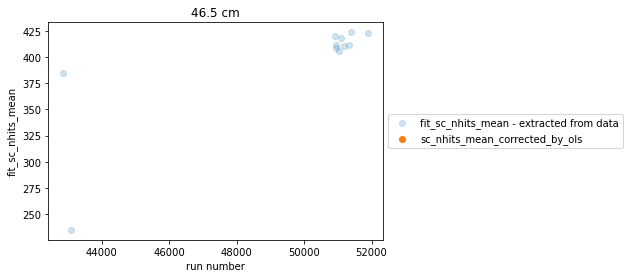

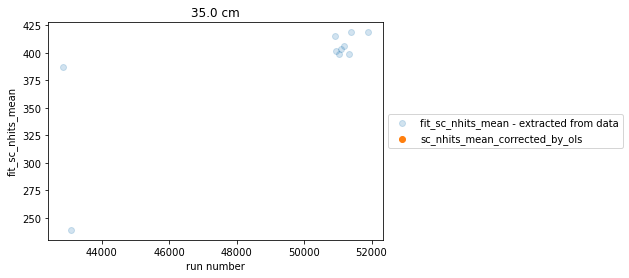

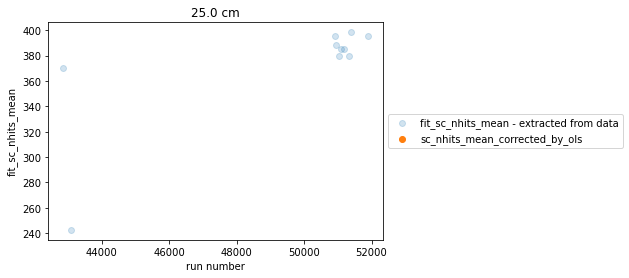

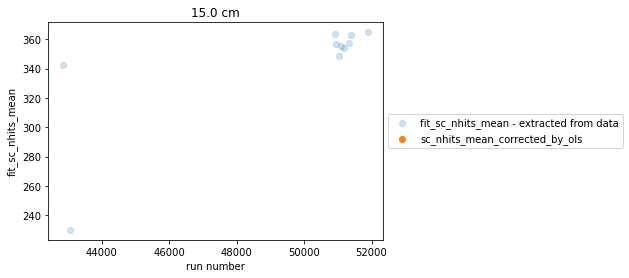

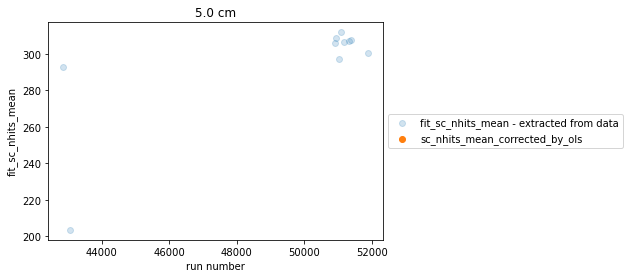

In [459]:
for position in result_df.corrected_source_position.unique():
    
    df_to_plot = result_df[(result_df.corrected_source_position == position).copy()
                                ]
    alpha = 0.2
    plt.scatter(df_to_plot.run, df_to_plot[f'fit_{sc_variable}_mean'], marker ='o', alpha = alpha, label = f'fit_{sc_variable}_mean - extracted from data' )
    for model in metrics_by_model.keys():
        label = f'{sc_variable}_mean_corrected_by_{model}'
        if model == 'ols': alpha = 1
        plt.scatter(df_to_plot.run, df_to_plot[label], marker ='o', alpha = alpha, label = label)
        alpha = 0.2
    #plt.scatter(df_to_plot.run, df_to_plot[f'corrected_sc_integral_ampl_TS'], marker ='o', color = 'red', label = f'corrected_sc_integral_ampl_TS' )
    plt.title(f"{position} cm")
    plt.xlabel('run number')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.ylabel(f'fit_{sc_variable}_mean')
    #plt.ylim(6600, 14000)
    plt.show()

In [460]:
result_df.columns

Index(['run', 'run_description', 'start_time', 'exposure_sec', 'GEM3_V',
       'GEM2_V', 'GEM1_V', 'T2_V', 'T1_V', 'DRIFT_V', 'OFFSET_V', 'PMT1_V',
       'PMT2_V', 'PMT3_V', 'PMT4_V', 'HV_STATE', 'total_gas_flow',
       'sequencer_running', 'sequence_filename', 'pmt_acquisition',
       'pedestal_run', 'source_type', 'source_position',
       'discrimination_threshold', 'trigger_veto_time', 'trigger_logic',
       'run_type', 'drs4_correction_active', 'shielding_configuration',
       'stop_time', 'number_of_events', 'storage_local_status',
       'storage_cloud_status', 'storage_tape_status', 'file_size',
       'file_checksum', 'file_s3_tag', 'online_reco_status', 'run_quality',
       'calibration_number', 'corrected_source_position', 'step',
       'fit_sc_nhits_ampl', 'fit_sc_nhits_mean', 'fit_sc_nhits_sigma',
       'Lime_pressure', 'Atm_pressure', 'Lime_temperature', 'Atm_temperature',
       'Humidity', 'Mixture_Density', 'P/T', 'sc_nhits_mean_corrected_by_ols'],
      dtype

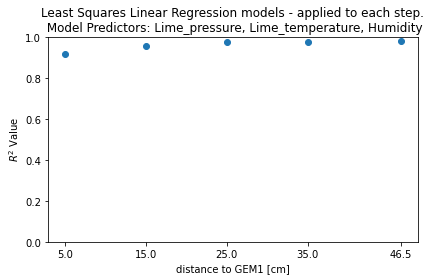

In [461]:
f"ploting the R^2 value for each of the model (position)"
x, y = list(R_values_by_position_dict.keys()), list(R_values_by_position_dict.values())
predictors_for_plot =", ".join(map(str, predictors))
plt.figure()
plt.plot(x, y, marker='o', linestyle='')   # no lines, only markers
plt.xticks(x)
plt.ylim(0,1)
plt.xlabel("distance to GEM1 [cm]")
plt.ylabel(f" $R^{2}$ Value")
plt.title(f"Least Squares Linear Regression models - applied to each step.\n Model Predictors: {predictors_for_plot}")

plt.savefig(os.path.join(main_folder_to_save, f'R_values_{sc_variable}_{predictors}_{gem3_V}.png'))
plt.tight_layout()
plt.show()

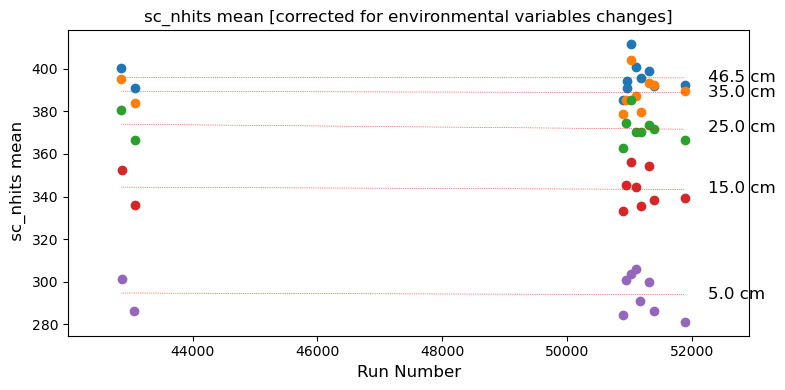

In [462]:
f"ploting corrected mean values of sc_integral distribution, vs run number"
regressions_per_position_dict = {}
mean_values_dict = {}
plt.figure(figsize=(8, 4), dpi=100)
for key, values in corrected_means_dict.items():
    runs = run_numbers_dict[key]
    key = f"{key} cm"
    x = runs
    y = values.values
    mean_values_dict[key] = y.mean()
    plt.plot(x, y, marker = 'o', linestyle='', linewidth = '.5', label=key)
    plt.annotate(key, xy=(x.max()*1.005, y.mean()), xytext=(5, 0), textcoords='offset points',
                 fontsize=12, color='black', va='center')
    # Fit a linear regression: get slope (m) and intercept (b)
    m, b = np.polyfit(x, y, 1,)
    regressions_per_position_dict[key]=[m,b]
    # Plot regression line
    plt.plot(x, m*x + b, color='red', linestyle='dotted', linewidth = '.5',#, label=f'Fit: y={m:.2f}x+{b:.2f}'
            )
    # Colocar labels próximos às últimas coordenadas dos dados
    
plt.xlim(x.min()*.98,x.max()*1.02)
plt.xlabel('Run Number', fontsize=12)
plt.ylabel(f' {sc_variable} mean', fontsize=12)
plt.title(f'{sc_variable} mean [corrected for environmental variables changes]')

plt.tight_layout()
#handles, labels = plt.gca().get_legend_handles_labels()
#plt.legend(handles[::-1], labels[::-1],loc='center left', bbox_to_anchor=(1, 0.5), title="Source Position")
plt.savefig(os.path.join(main_folder_to_save, f'{sc_variable}_corrected_{gem3_V}.png'))
plt.show()

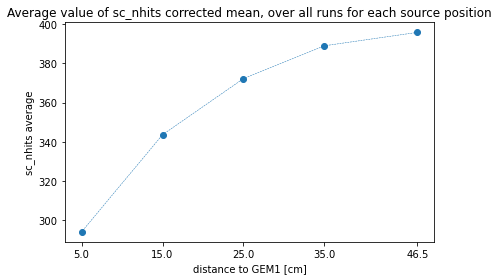

In [463]:
f"plotting the average value of the sc_integral corrected mean, vs position"
dict_to_extract_values_from = mean_values_dict
y = [y for y in dict_to_extract_values_from.values()]
#dict_to_extract_values_from = regressions_per_position_dict
#y = [y[1] for y in dict_to_extract_values_from.values()]
x = [float(x[:-3]) for x in dict_to_extract_values_from.keys()]

GEM_Voltage = selected_runs_df.GEM3_V.unique()[0]
x_label_position = 30
y_label_position = 1550#4#8000
if GEM_Voltage == 400: y_label_position = 1850#320

plt.plot(x,y, marker = 'o', linestyle = '--', linewidth = '.5')
plt.xticks(x)
plt.title(f"Average value of {sc_variable} corrected mean, over all runs for each source position")
plt.xlabel("distance to GEM1 [cm]")
plt.ylabel(f"{sc_variable} average")

#plt.text(x_label_position, y_label_position, f"GEM_V = {GEM_Voltage} V", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(main_folder_to_save, f'{sc_variable}_vs_distance_GEM_{GEM_Voltage}.png'))

plt.show()

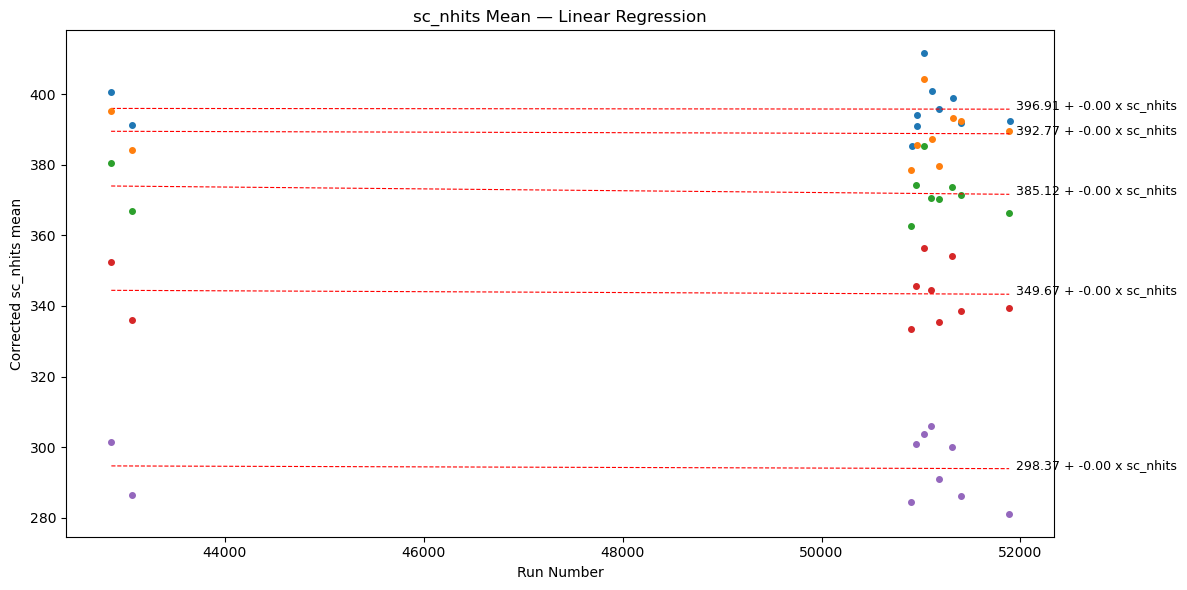

In [464]:
plt.figure(figsize=(12, 6), dpi=100)

regressions_per_position_dict = {}
mean_values_dict = {}

for key, values in corrected_means_dict.items():
    
    runs = run_numbers_dict[key]
    x = np.array(runs, dtype=float)
    y = np.array(values.values, dtype=float)

    key_label = f"{key} cm"
    mean_values_dict[key_label] = y.mean()

    # ---- PLOT DATA POINTS ----
    plt.plot(x, y, 'o', markersize=4, label=key_label)

    # ---- POLYFIT WITH COVARIANCE ----
    coeffs, cov = np.polyfit(x, y, 1, cov=True)
    m, b = coeffs

    m_err = np.sqrt(cov[0,0])   # uncertainty slope
    b_err = np.sqrt(cov[1,1])   # uncertainty intercept

    regressions_per_position_dict[key_label] = {
        "slope": m, "intercept": b,
        "slope_err": m_err, "intercept_err": b_err
    }

    # ---- REGRESSION LINE ----
    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = m * x_fit + b

    plt.plot(x_fit, y_fit, 'r--', linewidth=0.8)

    # ---- CONFIDENCE BAND (1σ) ----
    # formula: Var(y) = x^2 Var(m) + Var(b) + 2 x Cov(m,b)
    y_err = np.sqrt(
        (x_fit**2) * cov[0,0] +
        cov[1,1] +
        2 * x_fit * cov[0,1]
    )

    #plt.fill_between(x_fit, y_fit - y_err, y_fit + y_err, color='red', alpha=0.15)

    # ---- ANNOTATION WITH SLOPE ± ERROR ----
    plt.annotate(
        f"{b:2.2f} + {m:2.2f} x {sc_variable}",#f"{key_label}\n m={m:.2g}±{m_err:.1g}",
        xy=(x_fit[-1], y_fit[-1]),
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=9
    )

# ---- GLOBAL PLOT SETTINGS ----
plt.xlabel('Run Number')
plt.ylabel(f'Corrected {sc_variable} mean')
plt.title(f'{sc_variable} Mean — Linear Regression')

plt.tight_layout()
plt.show()

In [465]:
mean_fit_dict = {}
mean_fit_err_dict = {}

for key, values in corrected_means_dict.items():
    runs = run_numbers_dict[key]
    x = runs
    y = values.values

    # polyfit with covariance
    coeffs, cov = np.polyfit(x, y, 1, cov=True)
    m, b = coeffs

    m_err = np.sqrt(cov[0,0])
    b_err = np.sqrt(cov[1,1])

    # fitted values
    y_fit = m*x + b

    # mean fitted value:
    mean_fit = y_fit.mean()
    mean_fit_dict[key] = mean_fit

    # --- Compute error for the mean fitted value ---
    # variance of each fit point
    var_fit = (x**2)*(m_err**2) + (b_err**2)

    # variance of the mean of the fitted values
    mean_fit_err = np.sqrt(var_fit.sum()) / len(x)
    mean_fit_err_dict[key] = mean_fit_err

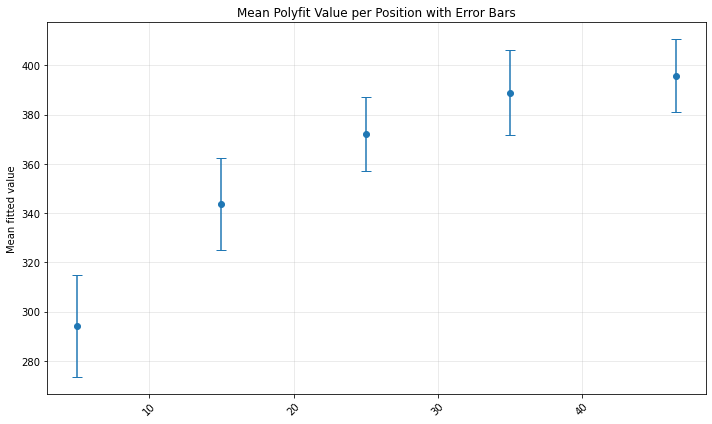

In [466]:
plt.figure(figsize=(10,6))

keys = list(mean_fit_dict.keys())
means = [mean_fit_dict[k] for k in keys]
errors = [mean_fit_err_dict[k] for k in keys]

plt.errorbar(
    keys,
    means,
    yerr=errors,
    fmt='o',
    capsize=5,
    markersize=6,
    label='Mean polyfit values'
)

plt.xticks(rotation=45)
plt.ylabel('Mean fitted value')
plt.title('Mean Polyfit Value per Position with Error Bars')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

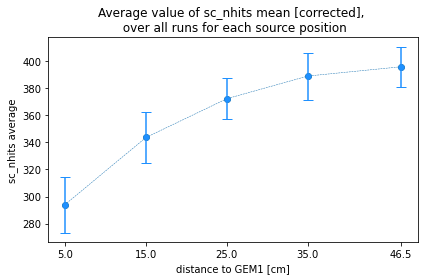

In [467]:
f"plotting the average value of the sc_integral corrected mean, vs position"
dict_to_extract_values_from = mean_values_dict
y = [y for y in dict_to_extract_values_from.values()]
#dict_to_extract_values_from = regressions_per_position_dict
#y = [y[1] for y in dict_to_extract_values_from.values()]
x = [float(x[:-3]) for x in dict_to_extract_values_from.keys()]

GEM_Voltage = selected_runs_df.GEM3_V.unique()[0]
x_label_position = 35
y_label_position = 9000#4#8000
if GEM_Voltage == 400: y_label_position = 500#300#3.5#1900#
    
plt.plot(x,y, marker = 'o', linestyle = '--', linewidth = '.5')
plt.xticks(x)
plt.title(f"Average value of {sc_variable} mean [corrected], \n over all runs for each source position")
plt.xlabel("distance to GEM1 [cm]")
plt.ylabel(f"{sc_variable} average")
#plt.text(x_label_position, y_label_position, f"GEM_V = {GEM_Voltage} V", fontsize=12)
plt.errorbar(
    keys,
    means,
    yerr=errors,
    fmt='o',
    capsize=5,
    markersize=5,
    label='Mean polyfit values',
    color = 'dodgerblue'
)
plt.tight_layout()
plt.savefig(os.path.join(main_folder_to_save, f'{sc_variable}_vs_distance_GEM_{GEM_Voltage}.png'))

plt.show()

In [468]:
agregate_results_df = pd.DataFrame({
    "GEM_Voltage": [GEM_Voltage] * len(keys),
    "distance_cm": keys,
    "mean_value": means,
    "error": errors
})

# Save CSV
save_path = os.path.join(main_folder_to_save, f"results_{sc_variable}_GEM_{GEM_Voltage}.csv")
agregate_results_df.to_csv(save_path, index=False)
print("Saved:", save_path)

Saved: 001_environmental_paramters_SAVE_DATA/results_sc_nhits_GEM_400.csv


In [203]:
list_files =  os.listdir(main_folder_to_save)
csv_files_list = [x for x in list_files if x[-3:]=='csv']
list_files[0][-3:]

'csv'

In [204]:
csv_files_list

['results_sc_integral_GEM_440.csv',
 'results_sc_tgausssigma_GEM_440.csv',
 'results_sc_nhits_GEM_440.csv',
 'results_sc_size_GEM_440.csv',
 'results_sc_tfullrms_GEM_400.csv',
 'results_sc_integral_GEM_400.csv',
 'results_sc_nhits_GEM_400.csv',
 'results_sc_size_GEM_400.csv',
 'results_sc_tfullrms_GEM_440.csv',
 'results_sc_tgausssigma_GEM_400.csv',
 'results_sc_rms_GEM_400.csv',
 'results_sc_rms_GEM_440.csv',
 'result_GEM_440.csv']

In [469]:
sc_variable =  'sc_integral'
sc_variable =  'sc_tgausssigma'
sc_variable =  'sc_nhits'
#sc_variable =  'sc_tfullrms'
#sc_variable =  'sc_size'
#sc_variable =  'sc_rms'
GEM_Voltage = 400
load_path = os.path.join(main_folder_to_save, f"results_{sc_variable}_GEM_{GEM_Voltage}.csv")
sc_integral_400_df = pd.read_csv(load_path)
GEM_Voltage = 440
load_path = os.path.join(main_folder_to_save, f"results_{sc_variable}_GEM_{GEM_Voltage}.csv")
sc_integral_440_df = pd.read_csv(load_path)

In [470]:
sc_integral_440_df

,GEM_Voltage,distance_cm,mean_value,error
0,440,5.0,436.393685,2.463390
1,440,15.0,562.568744,2.756996
2,440,25.0,683.430097,3.417878
3,440,35.0,775.216463,4.306989
4,440,46.5,847.754007,3.765531


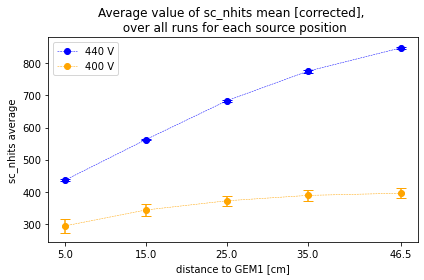

In [471]:
x = sc_integral_440_df.sort_values(by = 'distance_cm').distance_cm.values
y = sc_integral_440_df.sort_values(by = 'distance_cm').mean_value.values
plt.plot(x,y, marker = 'o', linestyle = '--', linewidth = '.5',   label = '440 V', color = 'blue')

plt.title(f"Average value of {sc_variable} mean [corrected], \n over all runs for each source position")
plt.xlabel("distance to GEM1 [cm]")
plt.ylabel(f"{sc_variable} average")
#plt.text(x_label_position, y_label_position, f"GEM_V = {GEM_Voltage} V", fontsize=12)

x = sc_integral_400_df.sort_values(by = 'distance_cm').distance_cm.values
y = sc_integral_400_df.sort_values(by = 'distance_cm').mean_value.values
plt.plot(x,y, marker = 'o', linestyle = '--', linewidth = '.5', label = '400 V', color = 'orange')
plt.legend()

plt.errorbar(
    x,
    sc_integral_400_df.sort_values(by = 'distance_cm').mean_value.values,
    yerr=sc_integral_400_df.sort_values(by = 'distance_cm').error.values,
    fmt='o',
   capsize=5,
    markersize=5,
   label='Mean polyfit values',
    color = 'orange'
)

plt.errorbar(
    x,
    sc_integral_440_df.sort_values(by = 'distance_cm').mean_value.values,
    yerr=sc_integral_440_df.sort_values(by = 'distance_cm').error.values,
    fmt='o',
    capsize=5,
    markersize=5,
    label='Mean polyfit values',
    color = 'blue'
)

plt.xticks(x)

plt.tight_layout()
plt.savefig(os.path.join(main_folder_to_save, f'{sc_variable}_GEM_VOLTAGE.png'))
plt.show()

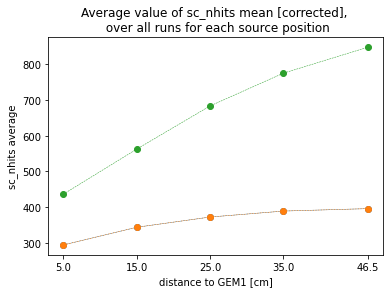

In [472]:
plt.plot(x,y, marker = 'o', linestyle = '--', linewidth = '.5')
plt.xticks(x)
plt.title(f"Average value of {sc_variable} mean [corrected], \n over all runs for each source position")
plt.xlabel("distance to GEM1 [cm]")
plt.ylabel(f"{sc_variable} average")

plt.plot( sc_integral_400_df.distance_cm, sc_integral_400_df.mean_value, marker = 'o', linestyle = '--', linewidth = '.5', label = '400 V')
plt.plot( sc_integral_440_df.distance_cm, sc_integral_440_df.mean_value,  marker = 'o', linestyle = '--', linewidth = '.5',label = '440 V')
plt.xticks(sc_integral_440_df.distance_cm)
plt.legend
plt.xlabel
plt.show()


In [473]:
sc_integral_400_df

,GEM_Voltage,distance_cm,mean_value,error
0,400,46.5,395.761813,14.820958
1,400,35.0,388.928296,17.350994
2,400,25.0,372.204917,15.009711
3,400,15.0,343.588942,18.695681
4,400,5.0,294.109466,20.616099


In [474]:
# Save CSV
save_path = os.path.join(main_folder_to_save, f"result_GEM_{GEM_Voltage}.csv")
result_df.to_csv(save_path, index=False)
print("Saved:", save_path)
result_df.columns

Saved: 001_environmental_paramters_SAVE_DATA/result_GEM_440.csv


Index(['run', 'run_description', 'start_time', 'exposure_sec', 'GEM3_V',
       'GEM2_V', 'GEM1_V', 'T2_V', 'T1_V', 'DRIFT_V', 'OFFSET_V', 'PMT1_V',
       'PMT2_V', 'PMT3_V', 'PMT4_V', 'HV_STATE', 'total_gas_flow',
       'sequencer_running', 'sequence_filename', 'pmt_acquisition',
       'pedestal_run', 'source_type', 'source_position',
       'discrimination_threshold', 'trigger_veto_time', 'trigger_logic',
       'run_type', 'drs4_correction_active', 'shielding_configuration',
       'stop_time', 'number_of_events', 'storage_local_status',
       'storage_cloud_status', 'storage_tape_status', 'file_size',
       'file_checksum', 'file_s3_tag', 'online_reco_status', 'run_quality',
       'calibration_number', 'corrected_source_position', 'step',
       'fit_sc_nhits_ampl', 'fit_sc_nhits_mean', 'fit_sc_nhits_sigma',
       'Lime_pressure', 'Atm_pressure', 'Lime_temperature', 'Atm_temperature',
       'Humidity', 'Mixture_Density', 'P/T', 'sc_nhits_mean_corrected_by_ols'],
      dtype

RMSE: 1.2645


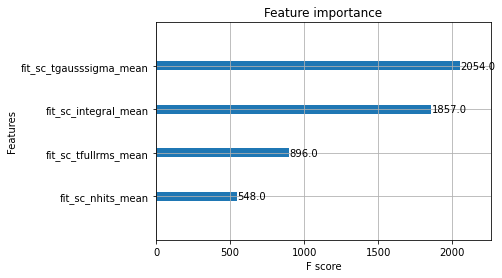

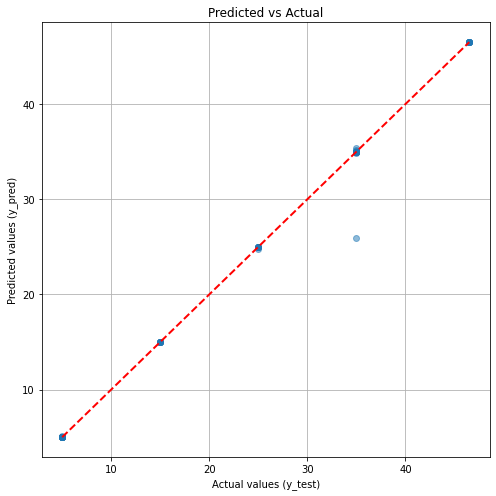

In [291]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor, plot_importance
estimators = ['fit_sc_integral_mean', 'fit_sc_tgausssigma_mean', 'fit_sc_tfullrms_mean',  'fit_sc_nhits_mean',
             ]
estimators_corr = ['sc_integral_mean_corrected_by_ols', 'sc_tgausssigma_mean_corrected_by_ols', 
              'sc_tfullrms_mean_corrected_by_ols',  'sc_nhits_mean_corrected_by_ols',
             ]

X = result_df[estimators_corr]
X = result_df[estimators]
y = result_df['corrected_source_position'].squeeze() 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror"
)

model = model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error
y_pred = model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"RMSE: {rmse:.4f}")


plot_importance(model, max_num_features=20)
plt.show()

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.5)
#sns.scatterplot(data=jagged_data_df,x="feature_x",y="feature_y", hue="group_column")


plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)

plt.xlabel("Actual values (y_test)")
plt.ylabel("Predicted values (y_pred)")
plt.title("Predicted vs Actual")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
jagged_data_df = jagged_data_df.merge(
    selected_runs_df[["run", 'corrected_source_position',]],
    on="run",
    how="left"
)

RMSE: 8.0696


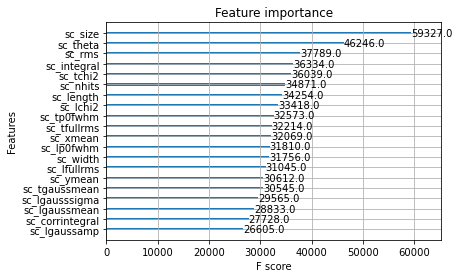

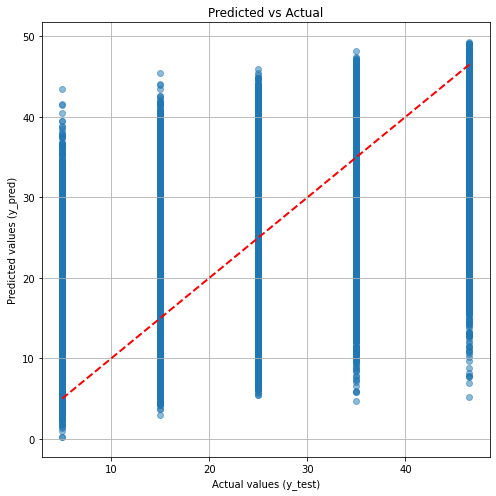

In [119]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor, plot_importance
estimators = ['sc_size', 'sc_nhits', 'sc_integral', 'sc_corrintegral', 'sc_rms',
       'sc_energy', 'sc_pathlength', 'sc_theta', 'sc_length', 'sc_width',
       #'sc_longrms', 'sc_latrms', 
              'sc_lfullrms', 'sc_tfullrms',
       'sc_lp0amplitude', 'sc_lp0prominence', 'sc_lp0fwhm', 'sc_lp0mean',
       'sc_tp0fwhm', 'sc_xmean', 'sc_ymean', 'sc_xmax', 'sc_xmin', 'sc_ymax',
       'sc_ymin', 'sc_pearson', 'sc_tgaussamp', 'sc_tgaussmean',
       #'sc_tgausssigma', 
              'sc_tchi2', 'sc_tstatus', 'sc_lgaussamp',
       'sc_lgaussmean', 'sc_lgausssigma', 'sc_lchi2', 'sc_lstatus'
             ]

X = jagged_data_df[estimators]
y = jagged_data_df['corrected_source_position'].squeeze() 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror"
)

model = model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error
y_pred = model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"RMSE: {rmse:.4f}")


plot_importance(model, max_num_features=20)
plt.show()

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.5)
#sns.scatterplot(data=jagged_data_df,x="feature_x",y="feature_y", hue="group_column")


plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)

plt.xlabel("Actual values (y_test)")
plt.ylabel("Predicted values (y_pred)")
plt.title("Predicted vs Actual")
plt.grid(True)
plt.tight_layout()
plt.show()


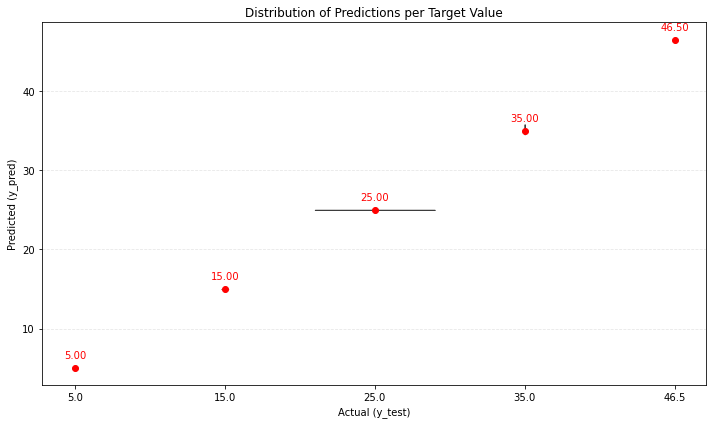

In [283]:
# Build a dataframe like before
df_plot = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})

plt.figure(figsize=(10, 6))

# Violin plot
sns.violinplot(
    data=df_plot,
    x="y_test",
    y="y_pred",
    inner=None,
    linewidth=1
)

# Compute medians
medians = df_plot.groupby("y_test")["y_pred"].median()

# Add median markers AND labels
for x_pos, (test_value, median_value) in enumerate(medians.items()):

    # Plot the median point
    plt.scatter(x_pos, median_value, color="red", zorder=5)

    # Write the median value next to the point
    plt.annotate(
        f"{median_value:.2f}",
        xy=(x_pos, median_value),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        color="red"
    )

plt.xlabel("Actual (y_test)")
plt.ylabel("Predicted (y_pred)")
plt.title("Distribution of Predictions per Target Value")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [121]:
selected_runs_df.columns

Index(['run', 'run_description', 'start_time', 'exposure_sec', 'GEM3_V',
       'GEM2_V', 'GEM1_V', 'T2_V', 'T1_V', 'DRIFT_V', 'OFFSET_V', 'PMT1_V',
       'PMT2_V', 'PMT3_V', 'PMT4_V', 'HV_STATE', 'total_gas_flow',
       'calibration_number', 'corrected_source_position', 'step',
       'fit_sc_integral_ampl', 'fit_sc_integral_mean', 'fit_sc_integral_sigma',
       'Lime_pressure', 'Atm_pressure', 'Lime_temperature', 'Atm_temperature',
       'Humidity', 'Mixture_Density', 'P/T',
       'sc_integral_mean_corrected_by_ols',
       'sc_integral_mean_corrected_by_xgb_reg',
       'sc_integral_mean_corrected_by_log_transform'],
      dtype='object')